# 1. Project Overview
## Credit Risk Probability of Default Modeling

This project builds an end-to-end Probability of Default (PD) model using the Home Credit dataset.

Objectives:
- Predict borrower default risk
- Build a robust credit scoring model
- Evaluate discrimination and calibration
- Simulate approval policy using PD cutoff

## Dataset

Source: Home Credit Default Risk

File used:
- application_train.csv

Target:
- TARGET (1 = default, 0 = non-default)

## Data Split Strategy

| Set | Size | Purpose |
|---|---|---|
| Train | 60% | Fit the model |
| Validation | 20% | Tune hyperparameters and select model |
| Test | 20% | Final evaluation — touched only once |
| OOT | last 20% chronologically | Temporal stability check |

# 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp

import lightgbm as lgb
import xgboost as xgb

# 3. Load Dataset
Dataset contains borrower demographic and financial information used to predict default.

In [2]:
df = pd.read_csv("dataset/application_train.csv")
print("Shape:", df.shape)
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Initial Data Exploration

### 4.1 Target Distribution

In [3]:
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

### 4.2 Missing Values

In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
dtype: float64

### 4.3 Data Types

In [5]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

### 4.4 Income vs Default

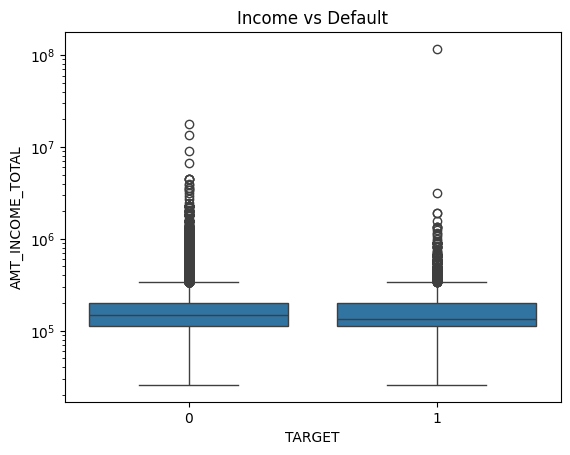

TARGET
0    148500.0
1    135000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [6]:
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df)
plt.yscale("log")
plt.title("Income vs Default")
plt.show()

df.groupby("TARGET")["AMT_INCOME_TOTAL"].median()

### 4.5 Age vs Default

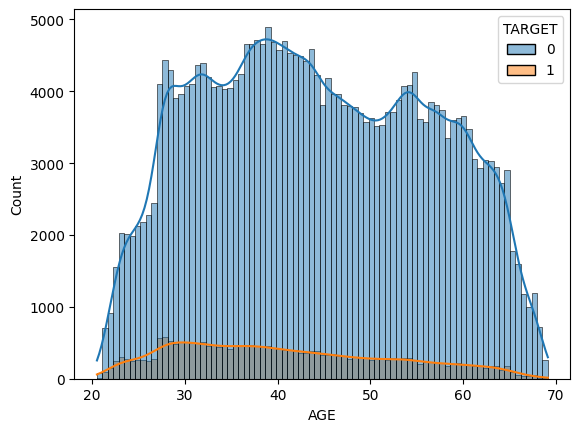

TARGET
0    44.214182
1    40.780351
Name: AGE, dtype: float64

In [7]:
df["AGE"] = df["DAYS_BIRTH"] / -365
sns.histplot(x="AGE", hue="TARGET", data=df, kde=True)
plt.show()

df.groupby("TARGET")["AGE"].mean()

### 4.6 Employment vs Default

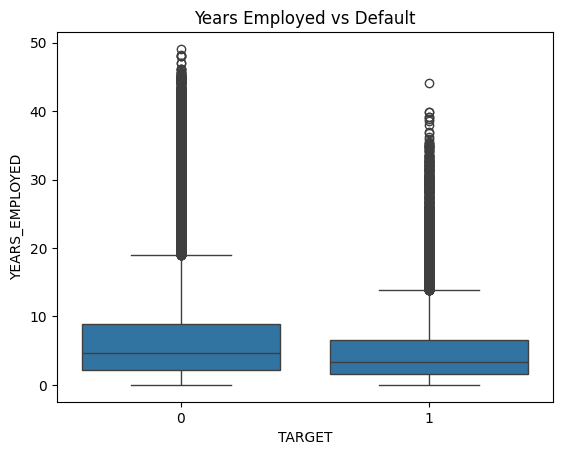

In [8]:
df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"] / -365
df.loc[df["YEARS_EMPLOYED"] < 0, "YEARS_EMPLOYED"] = None
df.loc[df["YEARS_EMPLOYED"] > 50, "YEARS_EMPLOYED"] = None

sns.boxplot(x="TARGET", y="YEARS_EMPLOYED", data=df)
plt.title("Years Employed vs Default")
plt.show()

# 5. Correlation Analysis
Initial correlation check on raw numeric features to understand which variables
are most linearly associated with the target.

In [9]:
corr = df.corr(numeric_only=True)["TARGET"].sort_values()

print("Top 10 Positive Correlation:")
print(corr.tail(10))

print("\nTop 10 Negative Correlation:")
print(corr.head(10))

Top 10 Positive Correlation:
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Top 10 Negative Correlation:
EXT_SOURCE_3      -0.178919
EXT_SOURCE_2      -0.160472
EXT_SOURCE_1      -0.155317
AGE               -0.078239
YEARS_EMPLOYED    -0.074958
DAYS_EMPLOYED     -0.044932
FLOORSMAX_AVG     -0.044003
FLOORSMAX_MEDI    -0.043768
FLOORSMAX_MODE    -0.043226
AMT_GOODS_PRICE   -0.039645
Name: TARGET, dtype: float64


# 6. Data Preprocessing

### 6.1 Drop High-Missing Columns
Columns with more than 80% missing values are dropped before splitting to avoid
carrying uninformative features into the model.

In [10]:
missing_ratio = df.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.8].index
df = df.drop(columns=high_missing_cols)
print("Dropped columns:", len(high_missing_cols))

Dropped columns: 0


### 6.2 Income Outlier Capping
Income distribution is highly skewed. We cap extreme values at the 99th percentile
to improve model stability. This is computed on the full dataset before splitting
as it is purely a data cleaning step.

In [11]:
income_cap = df["AMT_INCOME_TOTAL"].quantile(0.99)
df["AMT_INCOME_TOTAL"] = np.where(df["AMT_INCOME_TOTAL"] > income_cap, income_cap, df["AMT_INCOME_TOTAL"])

In [12]:
print("Income cap value:", income_cap)
print("Max income after capping:", df["AMT_INCOME_TOTAL"].max())
df["AMT_INCOME_TOTAL"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

Income cap value: 472500.0
Max income after capping: 472500.0


count    307511.000000
mean     166025.922341
std       83063.469251
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
95%      337500.000000
99%      472500.000000
max      472500.000000
Name: AMT_INCOME_TOTAL, dtype: float64

### 6.3 Employment Anomaly Flag
In the Home Credit dataset, some borrowers have DAYS_EMPLOYED = 365243,
which represents missing employment information.

We create an anomaly flag to capture this irregular value, then replace it
with NaN so it is treated as missing rather than an extreme duration.

In [13]:
df["EMPLOYED_ANOMALY"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

### 6.4 EXT_SOURCE Handling
EXT_SOURCE_1/2/3 are external credit scores with significant missing rates.
We create a missing indicator flag, impute with the median, and create a
combined mean feature.

In [14]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

for col in ext_cols:
    df[col + "_MISSING"] = df[col].isnull().astype(int)

for col in ext_cols:
    df[col] = df[col].fillna(df[col].median())

df["EXT_SOURCE_MEAN"] = df[ext_cols].mean(axis=1)

### 6.5 Advanced Ratio Features
Ratio features capture borrower leverage and repayment burden relative to income,
which are strong signals of credit risk.

In [15]:
df["CREDIT_TO_INCOME"]  = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_TO_ANNUITY"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]
df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
df["CREDIT_TO_AGE"]     = df["AMT_CREDIT"] / df["AGE"]

### 6.6 Final Correlation Check
Verify that the engineered features improve correlation with the target.

In [16]:
new_corr = df[[
    "TARGET",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_INCOME",
    "CREDIT_TO_ANNUITY",
    "INCOME_PER_PERSON",
    "CREDIT_TO_AGE",
    "EXT_SOURCE_MEAN",
    "EMPLOYED_ANOMALY",
    "AGE"
]].corr()["TARGET"].sort_values()

print(new_corr)

EXT_SOURCE_MEAN     -0.220840
AGE                 -0.078239
EMPLOYED_ANOMALY    -0.045987
CREDIT_TO_ANNUITY   -0.032102
INCOME_PER_PERSON   -0.014784
CREDIT_TO_INCOME    -0.008057
CREDIT_TO_AGE       -0.002729
ANNUITY_TO_INCOME    0.013852
TARGET               1.000000
Name: TARGET, dtype: float64


#  6.7 Feature Selection via Importance Screening
Train LightGBM temporarily on the entire data to identify features with
importance = 0 before the official split. Features that don't contribute at all
will be dropped to simplify the model.

In [17]:

X_temp = df.drop(columns=["TARGET", "SK_ID_CURR"])
X_temp = pd.get_dummies(X_temp, drop_first=True)
X_temp.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_temp.columns]  # tambah ini
y_temp = df["TARGET"]

X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

screening_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
screening_model.fit(X_tr, y_tr)

importance_screen = pd.DataFrame({
    "feature": X_tr.columns,
    "importance": screening_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Zero importance features:", (importance_screen["importance"] == 0).sum())
importance_screen.head(30)

Zero importance features: 85


,feature,importance
113,CREDIT_TO_ANNUITY,341
110,EXT_SOURCE_MEAN,150
29,EXT_SOURCE_3,117
9,DAYS_ID_PUBLISH,104
28,EXT_SOURCE_2,94
6,DAYS_BIRTH,91
3,AMT_ANNUITY,83
4,AMT_GOODS_PRICE,83
27,EXT_SOURCE_1,76
8,DAYS_REGISTRATION,76


In [ ]:
zero_importance_cols = importance_screen[importance_screen["importance"] == 0]["feature"].tolist()

cols_to_drop = [col for col in df.columns if col in zero_importance_cols]

df = df.drop(columns=cols_to_drop)
print("Dropped zero-importance columns:", len(cols_to_drop))

Dropped zero-importance columns: 21


In [19]:
print(df.shape)
print(cols_to_drop)

(307511, 113)
['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_EMAIL', 'LIVE_REGION_NOT_WORK_REGION', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'EMPLOYED_ANOMALY']


# 7. Split Data
Data is split into three sets: train (60%), validation (20%), and test (20%).
Stratification preserves the class ratio across all splits.

The test set is set aside immediately and **not used** until final evaluation.

In [ ]:
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train size     :", X_train.shape)
print("Validation size:", X_valid.shape)
print("Test size      :", X_test.shape)

Train size     : (184506, 111)
Validation size: (61502, 111)
Test size      : (61503, 111)


In [ ]:
ext_source_medians = {
    "EXT_SOURCE_1": X_train["EXT_SOURCE_1"].median(),
    "EXT_SOURCE_2": X_train["EXT_SOURCE_2"].median(),
    "EXT_SOURCE_3": X_train["EXT_SOURCE_3"].median(),
}
os.makedirs("model", exist_ok=True)
joblib.dump(ext_source_medians, "model/ext_source_medians.pkl")
print("EXT_SOURCE medians saved:", ext_source_medians)

EXT_SOURCE medians saved: {'EXT_SOURCE_1': 0.5059979305057544, 'EXT_SOURCE_2': 0.5659614260608526, 'EXT_SOURCE_3': 0.5352762504724826}


# 8. Categorical Encoding
One-hot encode categorical columns. Train is fit first, then validation and test
are aligned to train's columns to ensure identical feature sets.
Column names are sanitized to remove special characters required by LightGBM.

In [22]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_valid = pd.get_dummies(X_valid, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

X_train, X_valid = X_train.align(X_valid, join="left", axis=1, fill_value=0)
X_train, X_test  = X_train.align(X_test,  join="left", axis=1, fill_value=0)

X_train.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_valid.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_valid.columns]
X_test.columns  = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

print("Features:", X_train.shape[1])

Features: 219


# 9. Imputation for Logistic Regression
LightGBM and XGBoost handle NaN natively. Logistic Regression does not.
We apply median imputation using statistics learned only from the training set
to avoid data leakage into validation and test.

In [23]:
scaler = StandardScaler()
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index
)
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid_imp),
    columns=X_valid_imp.columns,
    index=X_valid_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns,
    index=X_test_imp.index
)

print("Remaining NaN in X_train_imp:", X_train_imp.isnull().sum().sum())

Remaining NaN in X_train_imp: 0


# 10. Model Training & Validation
Models are trained on `X_train` and evaluated on `X_valid` to compare performance
and guide model selection. The test set is not touched at this stage.

### 10.1 Logistic Regression

In [24]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred_valid = log_model.predict_proba(X_valid_scaled)[:, 1]
auc_log_valid = roc_auc_score(y_valid, log_pred_valid)
print("Logistic Regression — Validation AUC:", auc_log_valid)

Logistic Regression — Validation AUC: 0.746343173995744


### 10.2 LightGBM

In [25]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

lgb_pred_valid = lgb_model.predict_proba(X_valid)[:, 1]
auc_lgb_valid = roc_auc_score(y_valid, lgb_pred_valid)
print("LightGBM — Validation AUC:", auc_lgb_valid)

LightGBM — Validation AUC: 0.763102799954137


### 10.3 XGBoost

In [26]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred_valid = xgb_model.predict_proba(X_valid)[:, 1]
auc_xgb_valid = roc_auc_score(y_valid, xgb_pred_valid)
print("XGBoost — Validation AUC:", auc_xgb_valid)

XGBoost — Validation AUC: 0.763030662254153


### 10.4 Validation Comparison
Compare all models on the validation set to select the best model before
touching the test set.

In [27]:
print("=== Validation AUC Comparison ===")
print(f"Logistic Regression : {auc_log_valid:.5f}")
print(f"LightGBM            : {auc_lgb_valid:.5f}")
print(f"XGBoost             : {auc_xgb_valid:.5f}")
print()
print("Selected model: LightGBM")
print("Alasan: Perbedaan AUC dengan XGBoost tidak signifikan (0.00059).")
print("LightGBM dipilih karena training lebih cepat, lebih efisien di memory,")
print("dan memiliki dukungan SHAP yang lebih baik untuk interpretability.")

=== Validation AUC Comparison ===
Logistic Regression : 0.74634
LightGBM            : 0.76310
XGBoost             : 0.76303

Selected model: LightGBM
Alasan: Perbedaan AUC dengan XGBoost tidak signifikan (0.00059).
LightGBM dipilih karena training lebih cepat, lebih efisien di memory,
dan memiliki dukungan SHAP yang lebih baik untuk interpretability.


# 11. Feature Importance
Feature importance and SHAP analysis are based on the validation set
to guide feature selection before final test evaluation.

In [28]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
92,CREDIT_TO_ANNUITY,717
89,EXT_SOURCE_MEAN,412
25,EXT_SOURCE_3,343
9,DAYS_ID_PUBLISH,324
7,DAYS_EMPLOYED,280
8,DAYS_REGISTRATION,267
71,DAYS_LAST_PHONE_CHANGE,265
24,EXT_SOURCE_2,258
3,AMT_ANNUITY,232
4,AMT_GOODS_PRICE,231


### 11.2 SHAP Analysis

C:\Users\DELLworkstation\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


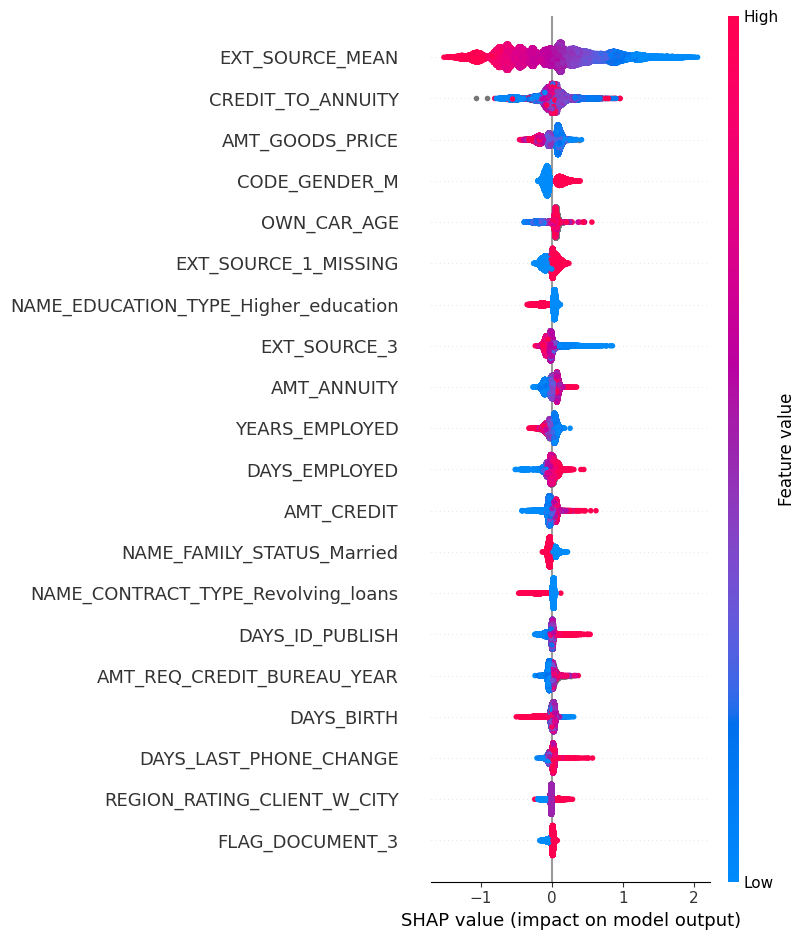

In [29]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_valid)

shap.summary_plot(shap_values, X_valid)

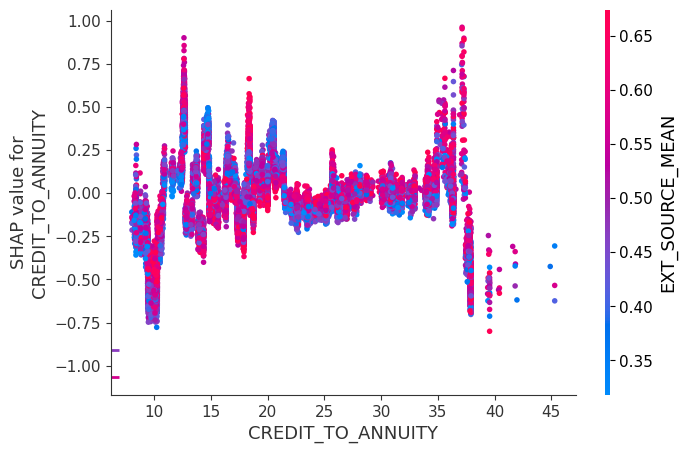

In [30]:
shap.dependence_plot("CREDIT_TO_ANNUITY", shap_values, X_valid)

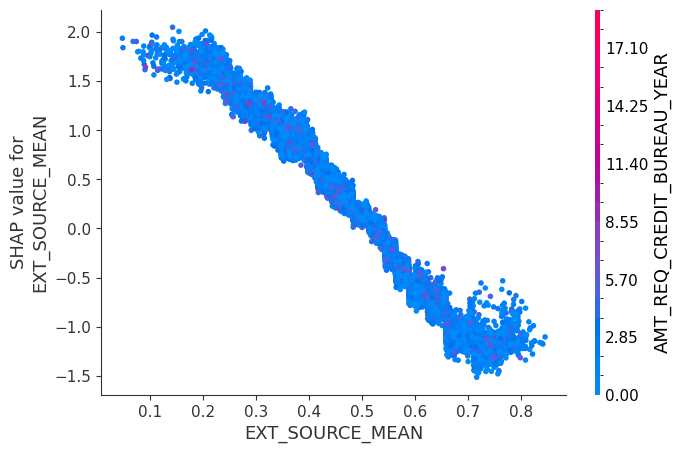

In [31]:
shap.dependence_plot("EXT_SOURCE_MEAN", shap_values, X_valid)

# 12. Cross-Validation (Stratified K-Fold)
Cross-validation is run on the training set only to get a robust estimate
of model performance without touching validation or test.

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)

    print(f"Fold {fold+1} AUC: {auc:.5f}")

print("Mean AUC:", np.mean(auc_scores))
print("Std AUC :", np.std(auc_scores))
print("Gini    :", 2 * np.mean(auc_scores) - 1)

Fold 1 AUC: 0.75605
Fold 2 AUC: 0.76359
Fold 3 AUC: 0.76275
Fold 4 AUC: 0.76343
Fold 5 AUC: 0.76244
Mean AUC: 0.7616524814672264
Std AUC : 0.0028319132713074233
Gini    : 0.5233049629344528


# 13. Final Model
After model selection on the validation set, retrain on train + validation combined
to maximize the data available before final test evaluation.

In [ ]:
X_trainval = pd.concat([X_train, X_valid])
y_trainval = pd.concat([y_train, y_valid])

final_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

final_model.fit(X_trainval, y_trainval)
print("Final model trained on", X_trainval.shape[0], "samples")

Final model trained on 246008 samples


# 14. Test Set Evaluation
The test set is evaluated **once** here using the final model.
This is the unbiased estimate of real-world performance.

In [34]:
y_test_pred = final_model.predict_proba(X_test)[:, 1]

good = y_test_pred[y_test == 0]
bad  = y_test_pred[y_test == 1]
ks_stat = ks_2samp(bad, good).statistic

test_auc  = roc_auc_score(y_test, y_test_pred)
test_gini = 2 * test_auc - 1

print("=== Test Set Results ===")
print("AUC          :", round(test_auc, 5))
print("Gini         :", round(test_gini, 5))
print("KS Statistic :", round(ks_stat, 5))

=== Test Set Results ===
AUC          : 0.76774
Gini         : 0.53548
KS Statistic : 0.39661


### 14.1 Decile Table (Test)

In [35]:
test_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred
})

test_df["decile"] = pd.qcut(test_df["y_pred"], 10, labels=False)
test_df["decile"] = 9 - test_df["decile"]

decile_table = test_df.groupby("decile").agg(
    total_apps=("y_true", "count"),
    total_bads=("y_true", "sum"),
    bad_rate=("y_true", "mean"),
    avg_score=("y_pred", "mean")
).reset_index().sort_values("decile", ascending=False)

decile_table["cum_apps"] = decile_table["total_apps"].cumsum()
decile_table["cum_bads"] = decile_table["total_bads"].cumsum()
decile_table["cum_bad_rate"] = decile_table["cum_bads"] / decile_table["cum_apps"]

print("\n===== DECILE TABLE — TEST SET =====\n")
print(decile_table)


===== DECILE TABLE — TEST SET =====

   decile  total_apps  total_bads  bad_rate  avg_score  cum_apps  cum_bads  \
9       9        6151          66  0.010730   0.011521      6151        66   
8       8        6150         116  0.018862   0.019596     12301       182   
7       7        6150         178  0.028943   0.026762     18451       360   
6       6        6150         201  0.032683   0.034895     24601       561   
5       5        6151         265  0.043082   0.044849     30752       826   
4       4        6150         361  0.058699   0.057691     36902      1187   
3       3        6150         510  0.082927   0.075351     43052      1697   
2       2        6150         591  0.096098   0.101401     49202      2288   
1       1        6150         914  0.148618   0.146537     55352      3202   
0       0        6151        1763  0.286620   0.279191     61503      4965   

   cum_bad_rate  
9      0.010730  
8      0.014796  
7      0.019511  
6      0.022804  
5      0.0268

### 14.2 Approval Rate Simulation (Test)

In [36]:
test_sorted = test_df.sort_values("y_pred", ascending=True).reset_index(drop=True)

approval_rates = [0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for rate in approval_rates:
    cutoff_index = int(len(test_sorted) * rate)
    approved = test_sorted.iloc[:cutoff_index]
    results.append({
        "approval_rate": rate,
        "approved_apps": len(approved),
        "portfolio_bad_rate": approved["y_true"].mean()
    })

cutoff_table = pd.DataFrame(results)
print("\n===== CUTOFF SIMULATION — TEST SET =====\n")
print(cutoff_table)


===== CUTOFF SIMULATION — TEST SET =====

   approval_rate  approved_apps  portfolio_bad_rate
0            0.5          30751            0.026861
1            0.6          36901            0.032167
2            0.7          43052            0.039417
3            0.8          49202            0.046502
4            0.9          55352            0.057848


### 14.3 Fairness Check by Age Group (Test)

In [37]:
fairness_df = X_test.copy()
fairness_df["TARGET"] = y_test.values
fairness_df["score"]  = y_test_pred

fairness_df["age"] = (-fairness_df["DAYS_BIRTH"] / 365).astype(int)
fairness_df["age_group"] = pd.cut(
    fairness_df["age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    right=False
)

threshold = np.percentile(fairness_df["score"], 70)
fairness_df["approved"] = (fairness_df["score"] <= threshold).astype(int)

age_stats = fairness_df.groupby("age_group").agg(
    total_apps=("TARGET", "count"),
    approval_rate=("approved", "mean"),
    bad_rate=("TARGET", "mean"),
    bad_rate_approved=("TARGET", lambda x: x[fairness_df.loc[x.index, "approved"] == 1].mean())
)

print(age_stats)

           total_apps  approval_rate  bad_rate  bad_rate_approved
age_group                                                        
[18, 25)         2382       0.433669  0.117548           0.038722
[25, 35)        14325       0.563490  0.105410           0.042616
[35, 45)        16893       0.695377  0.082638           0.039499
[45, 55)        14026       0.742621  0.073649           0.038786
[55, 65)        12161       0.838747  0.056163           0.038824
[65, 100)        1716       0.923077  0.036713           0.030934


C:\Users\DELLworkstation\AppData\Local\Temp\ipykernel_10628\4229648477.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = fairness_df.groupby("age_group").agg(


# 15. Out-of-Time (OOT) Validation
OOT validation splits data chronologically to simulate real-world model deployment.
The final model trained on train+validation is used here to predict on the OOT set.

### 15.1 OOT Split

In [38]:
X_full = df.drop(columns=["TARGET", "SK_ID_CURR"]).copy()
y_full = df["TARGET"].copy()

X_full = pd.get_dummies(X_full, drop_first=True)
X_full.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_full.columns]

X_full["TIME_SORT"] = df["DAYS_ID_PUBLISH"].values
X_full = X_full.sort_values("TIME_SORT")
y_full = y_full.loc[X_full.index]

split_index = int(len(X_full) * 0.80)

X_train_oot = X_full.iloc[:split_index].drop(columns=["TIME_SORT"])
X_oot       = X_full.iloc[split_index:].drop(columns=["TIME_SORT"])
y_train_oot = y_full.iloc[:split_index]
y_oot       = y_full.iloc[split_index:]

print("OOT Train size:", X_train_oot.shape)
print("OOT Test  size:", X_oot.shape)

OOT Train size: (246008, 219)
OOT Test  size: (61503, 219)


### 15.2 OOT Model Training

In [39]:
oot_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose = -1
)

oot_model.fit(X_train_oot, y_train_oot)

train_pred_oot = oot_model.predict_proba(X_train_oot)[:, 1]
oot_pred       = oot_model.predict_proba(X_oot)[:, 1]

train_auc_oot = roc_auc_score(y_train_oot, train_pred_oot)
oot_auc       = roc_auc_score(y_oot, oot_pred)

print("OOT TRAIN AUC:", round(train_auc_oot, 6))
print("OOT TEST  AUC:", round(oot_auc, 6))
print("AUC DROP      :", round(train_auc_oot - oot_auc, 6))

OOT TRAIN AUC: 0.797774
OOT TEST  AUC: 0.760009
AUC DROP      : 0.037765


# 16. Model Stability (PSI)
Population Stability Index (PSI) measures how much the score distribution
has shifted between train and OOT. PSI < 0.1 is stable, 0.1–0.2 needs monitoring,
> 0.2 indicates significant shift.

### 16.1 PSI Function

In [40]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    expected_counts = np.histogram(expected, breakpoints)[0]
    actual_counts   = np.histogram(actual, breakpoints)[0]

    expected_perc = expected_counts / len(expected)
    actual_perc   = actual_counts / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc   = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi

### 16.2 Score PSI

In [41]:
score_psi = calculate_psi(train_pred_oot, oot_pred)
print("Score PSI:", round(score_psi, 6))

Score PSI: 0.079069


### 16.3 Feature PSI (Top 20)

In [42]:
importance = pd.Series(
    oot_model.feature_importances_,
    index=X_train_oot.columns
).sort_values(ascending=False)

top20 = importance.head(20).index

psi_dict = {col: calculate_psi(X_train_oot[col], X_oot[col]) for col in top20}

psi_df = pd.DataFrame.from_dict(psi_dict, orient="index", columns=["PSI"])
psi_df = psi_df.sort_values("PSI", ascending=False)
psi_df.head(10)

,PSI
DAYS_ID_PUBLISH,7.013692
AGE,1.394687
DAYS_BIRTH,1.394634
DAYS_EMPLOYED,0.229433
YEARS_EMPLOYED,0.229433
EXT_SOURCE_3,0.064496
DAYS_LAST_PHONE_CHANGE,0.051361
DAYS_REGISTRATION,0.049896
EXT_SOURCE_MEAN,0.039595
CREDIT_TO_AGE,0.037738


### 16.4 Score Distribution: Train vs OOT

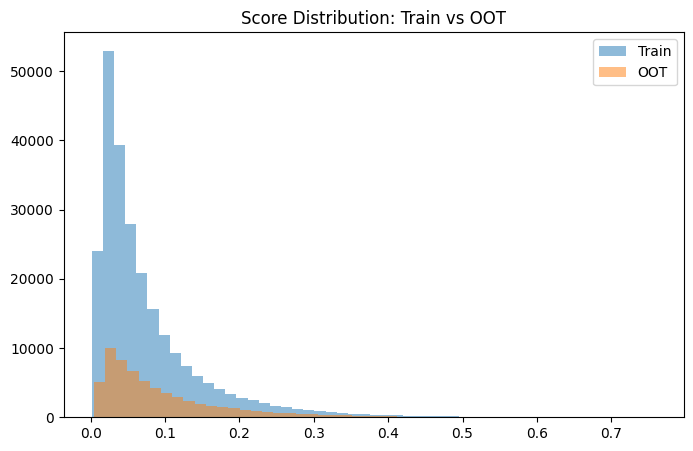

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(train_pred_oot, bins=50, alpha=0.5, label="Train")
plt.hist(oot_pred, bins=50, alpha=0.5, label="OOT")
plt.legend()
plt.title("Score Distribution: Train vs OOT")
plt.show()

# 17. Calibration
Calibration measures how well predicted probabilities match observed default rates.
A well-calibrated model produces PD estimates that can be trusted as actual probabilities.

### 17.1 Brier Score (OOT)

In [44]:
brier_oot = brier_score_loss(y_oot, oot_pred)
print("Brier Score OOT:", round(brier_oot, 6))

Brier Score OOT: 0.081063


### 17.2 Calibration Curve (OOT)

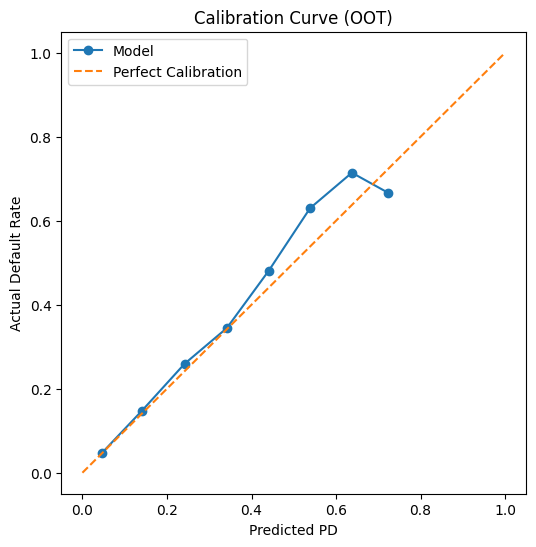

In [45]:
prob_true, prob_pred = calibration_curve(y_oot, oot_pred, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0, 1], [0, 1], '--', label="Perfect Calibration")
plt.title("Calibration Curve (OOT)")
plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.legend()
plt.show()

### 17.3 Decile Table (OOT)

In [46]:
oot_df = pd.DataFrame({
    "TARGET": y_oot,
    "PD": oot_pred
})

oot_df["DECILE"] = pd.qcut(oot_df["PD"], 10, labels=False)

decile_table_oot = oot_df.groupby("DECILE").agg(
    count=("TARGET", "count"),
    avg_pd=("PD", "mean"),
    actual_dr=("TARGET", "mean")
).sort_index(ascending=False)

decile_table_oot

,count,avg_pd,actual_dr
DECILE,,,
9,6151,0.303079,0.321736
8,6150,0.176749,0.192520
7,6150,0.126944,0.127154
6,6150,0.096696,0.098699
5,6150,0.075067,0.081138
4,6151,0.058683,0.060315
3,6150,0.045493,0.046667
2,6150,0.034533,0.035447
1,6150,0.024970,0.023577


# 18. Cutoff Policy Simulation
Simulate the business impact of different PD cutoff thresholds using the OOT set
to support credit policy decisions under realistic temporal conditions.

### 18.1 Approval Rate vs Bad Rate

In [47]:
cutoffs = np.arange(0.01, 0.31, 0.01)
simulation = []

for c in cutoffs:
    approved = oot_df[oot_df["PD"] <= c]
    approval_rate = len(approved) / len(oot_df)
    bad_rate = approved["TARGET"].mean() if len(approved) > 0 else np.nan
    simulation.append({"cutoff": c, "approval_rate": approval_rate, "bad_rate": bad_rate})

simulation_df = pd.DataFrame(simulation)
simulation_df.head(10)

,cutoff,approval_rate,bad_rate
0,0.01,0.011008,0.004431
1,0.02,0.094727,0.011672
2,0.03,0.204933,0.018248
3,0.04,0.303546,0.023729
4,0.05,0.386632,0.028975
5,0.06,0.459766,0.032783
6,0.07,0.523194,0.037324
7,0.08,0.576427,0.041408
8,0.09,0.622929,0.044816
9,0.10,0.664618,0.048146


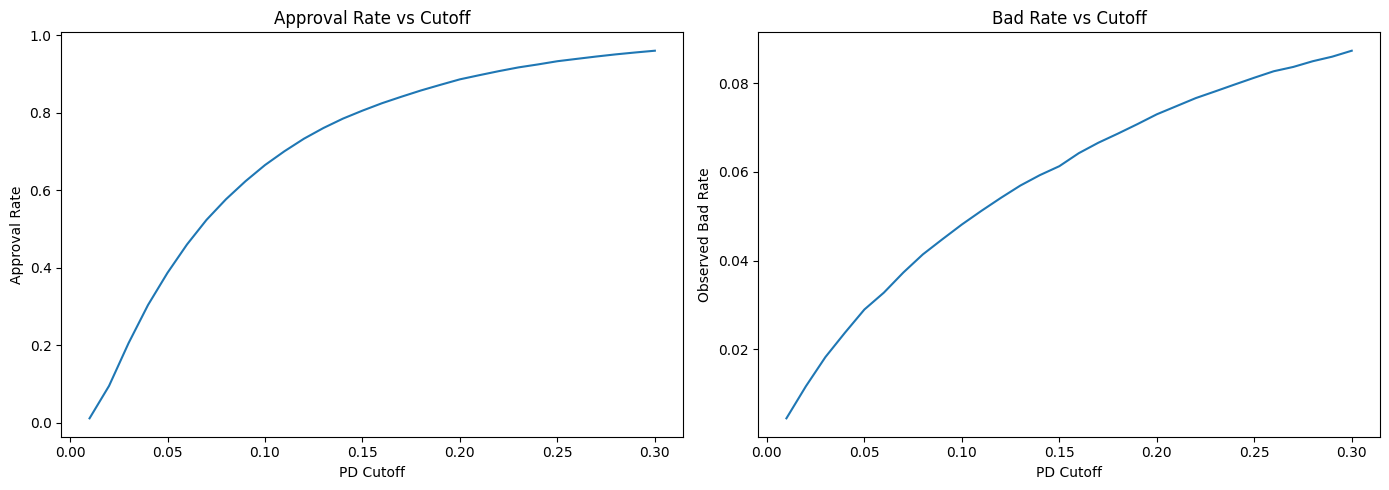

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(simulation_df["cutoff"], simulation_df["approval_rate"])
axes[0].set_title("Approval Rate vs Cutoff")
axes[0].set_xlabel("PD Cutoff")
axes[0].set_ylabel("Approval Rate")

axes[1].plot(simulation_df["cutoff"], simulation_df["bad_rate"])
axes[1].set_title("Bad Rate vs Cutoff")
axes[1].set_xlabel("PD Cutoff")
axes[1].set_ylabel("Observed Bad Rate")

plt.tight_layout()
plt.show()

### 18.2 Expected Loss Simulation

In [49]:
LGD = 0.6
simulation_el = []

for c in simulation_df["cutoff"]:
    approved = oot_df[oot_df["PD"] <= c]
    approval_rate = len(approved) / len(oot_df)
    if len(approved) > 0:
        bad_rate = approved["TARGET"].mean()
        portfolio_el = bad_rate * LGD
    else:
        bad_rate = np.nan
        portfolio_el = np.nan
    simulation_el.append({
        "cutoff": c,
        "approval_rate": approval_rate,
        "bad_rate": bad_rate,
        "portfolio_EL": portfolio_el
    })

simulation_el_df = pd.DataFrame(simulation_el)
simulation_el_df.head(10)

,cutoff,approval_rate,bad_rate,portfolio_EL
0,0.01,0.011008,0.004431,0.002659
1,0.02,0.094727,0.011672,0.007003
2,0.03,0.204933,0.018248,0.010949
3,0.04,0.303546,0.023729,0.014238
4,0.05,0.386632,0.028975,0.017385
5,0.06,0.459766,0.032783,0.019670
6,0.07,0.523194,0.037324,0.022394
7,0.08,0.576427,0.041408,0.024845
8,0.09,0.622929,0.044816,0.026890
9,0.10,0.664618,0.048146,0.028887


### 18.3 Portfolio Profit Simulation

In [50]:
interest = 0.25
LGD = 0.6
profit_sim = []

for c in simulation_df["cutoff"]:
    approved = oot_df[oot_df["PD"] <= c]
    approval_rate = len(approved) / len(oot_df)
    if len(approved) > 0:
        dr = approved["TARGET"].mean()
        expected_profit_per_loan = (1 - dr) * interest - dr * LGD
        portfolio_profit = expected_profit_per_loan * approval_rate
    else:
        dr = np.nan
        expected_profit_per_loan = np.nan
        portfolio_profit = np.nan
    profit_sim.append({
        "cutoff": c,
        "approval_rate": approval_rate,
        "bad_rate": dr,
        "profit_per_loan": expected_profit_per_loan,
        "portfolio_profit": portfolio_profit
    })

profit_df = pd.DataFrame(profit_sim)
profit_df.sort_values("portfolio_profit", ascending=False).head(10)

,cutoff,approval_rate,bad_rate,profit_per_loan,portfolio_profit
26,0.27,0.944751,0.083676,0.178875,0.168993
28,0.29,0.955189,0.085996,0.176904,0.168976
27,0.28,0.950311,0.084966,0.177779,0.168945
24,0.25,0.932589,0.081246,0.180941,0.168744
25,0.26,0.938718,0.082707,0.179699,0.168687
29,0.30,0.959709,0.087336,0.175765,0.168683
23,0.24,0.924296,0.079723,0.182236,0.168440
22,0.23,0.916622,0.078173,0.183553,0.168249
21,0.22,0.907029,0.076651,0.184846,0.167661
20,0.21,0.896623,0.074821,0.186402,0.167132


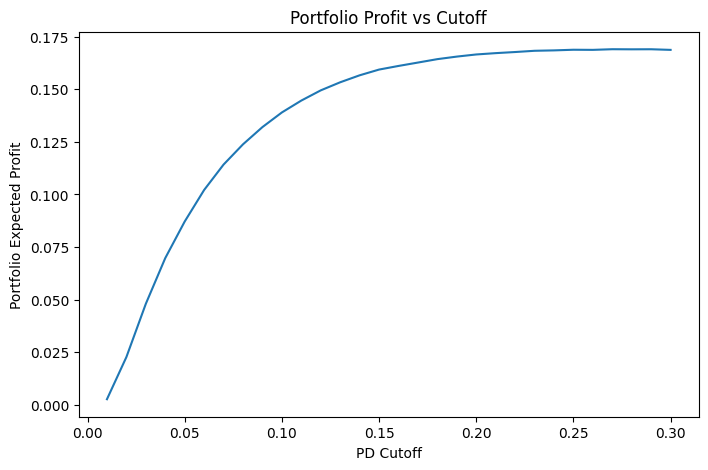

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(profit_df["cutoff"], profit_df["portfolio_profit"])
plt.title("Portfolio Profit vs Cutoff")
plt.xlabel("PD Cutoff")
plt.ylabel("Portfolio Expected Profit")
plt.show()

### 18.4 Stress Testing

In [52]:
scenarios = [
    {"interest": 0.25, "LGD": 0.6, "name": "Base"},
    {"interest": 0.25, "LGD": 0.7, "name": "High LGD"},
    {"interest": 0.20, "LGD": 0.6, "name": "Low Interest"},
]

stress_results = []

for sc in scenarios:
    for c in simulation_df["cutoff"]:
        approved = oot_df[oot_df["PD"] <= c]
        approval_rate = len(approved) / len(oot_df)
        if len(approved) > 0:
            dr = approved["TARGET"].mean()
            exp_profit = (1 - dr) * sc["interest"] - dr * sc["LGD"]
            portfolio_profit = exp_profit * approval_rate
        else:
            dr = np.nan
            portfolio_profit = np.nan
        stress_results.append({
            "scenario": sc["name"],
            "cutoff": c,
            "portfolio_profit": portfolio_profit
        })

stress_df = pd.DataFrame(stress_results)
stress_df.sort_values(["scenario", "portfolio_profit"], ascending=[True, False]).groupby("scenario").head(3)

,scenario,cutoff,portfolio_profit
26,Base,0.27,0.168993
28,Base,0.29,0.168976
27,Base,0.28,0.168945
54,High LGD,0.25,0.161167
56,High LGD,0.27,0.161087
52,High LGD,0.23,0.161083
82,Low Interest,0.23,0.126000
83,Low Interest,0.24,0.125909
84,Low Interest,0.25,0.125903


# 19. Final Credit Decision
Set the final PD cutoff based on the profit simulation and business tolerance,
then summarize the resulting portfolio metrics on the OOT set.

In [53]:
FINAL_CUTOFF = 0.25

def credit_decision(pd_score):
    return "APPROVE" if pd_score <= FINAL_CUTOFF else "REJECT"

approved = oot_df[oot_df["PD"] <= FINAL_CUTOFF]

print("=== Final Policy Summary (OOT) ===")
print("PD Cutoff      :", FINAL_CUTOFF)
print("Approval Rate  :", round(len(approved) / len(oot_df), 4))
print("Bad Rate       :", round(approved["TARGET"].mean(), 4))
print("Expected Loss  :", round(approved["TARGET"].mean() * 0.6, 4))
print("Overall OOT DR :", round(y_oot.mean(), 4))

=== Final Policy Summary (OOT) ===
PD Cutoff      : 0.25
Approval Rate  : 0.9326
Bad Rate       : 0.0812
Expected Loss  : 0.0487
Overall OOT DR : 0.0999


In [ ]:
joblib.dump(final_model, "model/final_model.pkl")

joblib.dump(income_cap, "model/income_cap.pkl")

joblib.dump(list(X_train.columns), "model/feature_columns.pkl")

print("=== Artefak berhasil disimpan ===")
print(f"Model     : model/final_model.pkl ({os.path.getsize('model/final_model.pkl') / 1e6:.1f} MB)")
print(f"Income cap: {income_cap:,.0f}")
print(f"Features  : {len(X_train.columns)} kolom")
print("\nSample kolom pertama:", list(X_train.columns)[:5])

=== Artefak berhasil disimpan ===
Model     : model/final_model.pkl (1.8 MB)
Income cap: 472,500
Features  : 219 kolom

Sample kolom pertama: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
